In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report,confusion_matrix

from sklearn.preprocessing import LabelEncoder

import matplotlib.pyplot as plt
from collections import Counter
import seaborn as sns

from spacy.lang.en.stop_words import STOP_WORDS as en_stop



# Processing data

In [9]:
# Variable
percentage_genre_to_keep = 25
test_size = 0.2
random_state = 42

In [ ]:
df = pd.read_csv("../data/MovieDataThread.csv")
index_drop = df.loc[df['imdb_id'].isnull()].index
df = df.drop(index=index_drop)
df = df.drop(columns=['imdb_id'])
df_filtered = pd.concat([df[['Script','Title']],df.filter(like='imdb_')],axis=1)
df_filtered["genre_count"] = df_filtered.filter(regex='^imdb_(?!id$)').count(axis=1)
df_filtered_one_genre = df_filtered.loc[df_filtered['genre_count'] == 1]
df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)
number_genres = len(df_filtered_one_genre['filtered_genre'].unique())
counter = Counter(df_filtered_one_genre['filtered_genre'])
sorted_list = sorted(counter.items(),reverse=True , key=lambda genre : genre[1])[: int(number_genres * (percentage_genre_to_keep / 100))]

genre_to_keep = [genre for genre,_ in sorted_list]
columns_to_keep = ['Script','filtered_genre']

df_movies = df_filtered_one_genre.loc[df_filtered_one_genre['filtered_genre'].isin(genre_to_keep)]
df_movies = df_movies[columns_to_keep].reset_index(drop=True)


# Training and test

In [18]:
X_train,X_test , y_train,y_test = train_test_split(df_movies['Script'],df_movies['filtered_genre'],test_size=test_size,random_state=random_state)

encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)

d:\programmation\nlp\.venv\lib\site-packages\sklearn\feature_extraction\text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ll', 've'] not in stop_words.
  warnings.warn(


Classification Report:
                   precision    recall  f1-score   support

     imdb_comedy       0.52      0.66      0.58       314
imdb_documentary       0.89      0.80      0.84       251
      imdb_drama       0.66      0.73      0.69       609
     imdb_horror       0.62      0.56      0.59       171
    imdb_romance       0.84      0.26      0.40        61
   imdb_thriller       0.67      0.36      0.47       138

        accuracy                           0.65      1544
       macro avg       0.70      0.56      0.59      1544
    weighted avg       0.67      0.65      0.65      1544



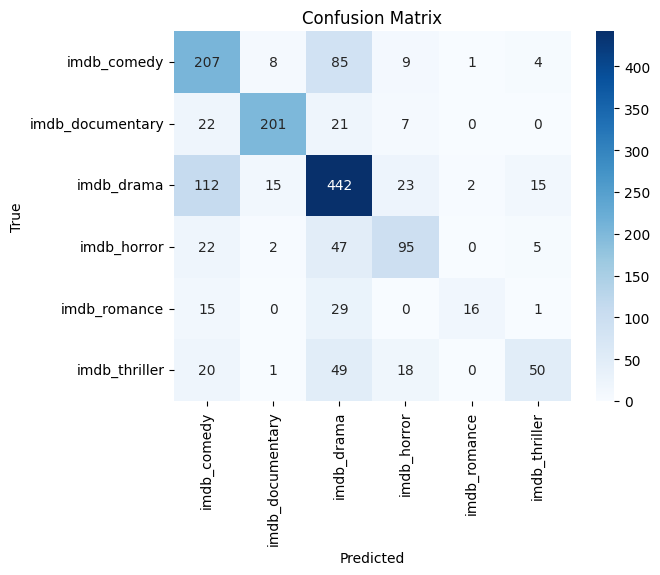

In [ ]:
model = make_pipeline(CountVectorizer(ngram_range = (1,1), stop_words = list(en_stop)), MultinomialNB())
model.fit(X_train, y_train_encoded)
y_pred = model.predict(X_test)
print(f"Classification Report:\n", classification_report(y_test, encoder.inverse_transform(y_pred)))
cm = confusion_matrix(y_test_encoded, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Augmentation data

In [2]:
import pandas as pd
import random
import nltk
from nltk.corpus import wordnet
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package punkt to /home/pierre/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /home/pierre/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/pierre/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /home/pierre/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /home/pierre/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!


True

In [3]:
percentage_genre_to_keep = 25
test_size = 0.2
random_state = 42

In [4]:
df = pd.read_csv("../data/MovieDataThread.csv")
index_drop = df.loc[df['imdb_id'].isnull()].index
df = df.drop(index=index_drop)
df = df.drop(columns=['imdb_id'])
df_filtered = pd.concat([df[['Script','Title']],df.filter(like='imdb_')],axis=1)
df_filtered["genre_count"] = df_filtered.filter(regex='^imdb_(?!id$)').count(axis=1)
df_filtered_one_genre = df_filtered.loc[df_filtered['genre_count'] == 1]
df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)
number_genres = len(df_filtered_one_genre['filtered_genre'].unique())
counter = Counter(df_filtered_one_genre['filtered_genre'])
sorted_list = sorted(counter.items(),reverse=True , key=lambda genre : genre[1])[: int(number_genres * (percentage_genre_to_keep / 100))]

genre_to_keep = [genre for genre,_ in sorted_list]
columns_to_keep = ['Script','filtered_genre']

df_movies = df_filtered_one_genre.loc[df_filtered_one_genre['filtered_genre'].isin(genre_to_keep)]
df_movies = df_movies[columns_to_keep].reset_index(drop=True)


/tmp/ipykernel_8766/2146986483.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_one_genre['filtered_genre'] = df_filtered_one_genre.apply(lambda row: next(iter([col for col in df_filtered_one_genre.columns if "imdb" in col and row[col] == 1.0 ]), 'unknown'), axis=1)


In [5]:
X_train,X_test , y_train,y_test = train_test_split(df_movies['Script'],df_movies['filtered_genre'],test_size=test_size,random_state=random_state)

In [6]:
len(X_train), len(y_train)

(6176, 6176)

In [ ]:
# Perform augmentation
stop_words = set(stopwords.words("english"))

# Mapping NLTK POS → WordNet POS
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return None

def get_synonym(word, tag):
    wn_tag = get_wordnet_pos(tag)
    if wn_tag is None:
        return word

    synsets = wordnet.synsets(word, pos=wn_tag)
    if not synsets:
        return word

    lemmas = [lemma.name().replace("_", " ") for syn in synsets for lemma in syn.lemmas()
              if lemma.name().lower() != word.lower()]
    return random.choice(lemmas) if lemmas else word

def synonym_augment(text):
    words = word_tokenize(text)
    tagged_words = nltk.pos_tag(words)
    new_words = []

    for word, tag in tagged_words:
        if word.lower() not in stop_words and word.isalpha():
            synonym = get_synonym(word, tag)
            new_words.append(synonym)
        else:
            new_words.append(word)

    return ' '.join(new_words)

# Augment underrepresented genres
thriller_romance_indices = y_train[(y_train == 'imdb_thriller') | (y_train == 'imdb_romance')].index
thriller_romance_script = X_train.loc[thriller_romance_indices].apply(synonym_augment)

X_train = pd.concat([X_train, thriller_romance_script], ignore_index=True)
y_train = pd.concat([y_train, y_train.loc[thriller_romance_indices]], ignore_index=True)

encoder = LabelEncoder()
y_train_encoded = encoder.fit_transform(y_train)
y_test_encoded = encoder.transform(y_test)


In [8]:
y_train

0            imdb_comedy
1       imdb_documentary
2          imdb_thriller
3          imdb_thriller
4       imdb_documentary
              ...       
6877       imdb_thriller
6878       imdb_thriller
6879       imdb_thriller
6880        imdb_romance
6881       imdb_thriller
Name: filtered_genre, Length: 6882, dtype: object

In [9]:
y_train_encoded

array([0, 1, 5, ..., 5, 4, 5])

In [10]:
X_train

0       Who the...\n Stay here, don't do anything, OK?...
1       Dave Karsnia over tape:\n All right.\n The dat...
2       Wow!\n Race you to the top?\n Umm...\n How is ...
3       1\n Yes, Ma?\n We're almost at the terminal.\n...
4       Sudan Electricity Company.\n Welcome to Custom...
                              ...                        
6877    1 ( piss spray ) ( cap mess up ) ( abstemious ...
6878    1 [ ill medicine ] [ missy ] fairy bluebird , ...
6879    surface-to-air missile . surface-to-air missil...
6880    Hey , Trevor . Where are you ? The demarcation...
6881    add up on . total on ... You can do this ... H...
Name: Script, Length: 6882, dtype: object

In [11]:
len(X_train)

6882

/home/pierre/miniconda3/envs/ia/lib/python3.9/site-packages/sklearn/feature_extraction/text.py:402: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['ll', 've'] not in stop_words.
  warnings.warn(


Classification Report:
                   precision    recall  f1-score   support

     imdb_comedy       0.49      0.67      0.57       314
imdb_documentary       0.88      0.80      0.84       251
      imdb_drama       0.63      0.74      0.68       609
     imdb_horror       0.56      0.56      0.56       171
    imdb_romance       0.00      0.00      0.00        61
   imdb_thriller       0.00      0.00      0.00       138

        accuracy                           0.62      1544
       macro avg       0.43      0.46      0.44      1544
    weighted avg       0.55      0.62      0.58      1544



/home/pierre/miniconda3/envs/ia/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/pierre/miniconda3/envs/ia/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/pierre/miniconda3/envs/ia/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

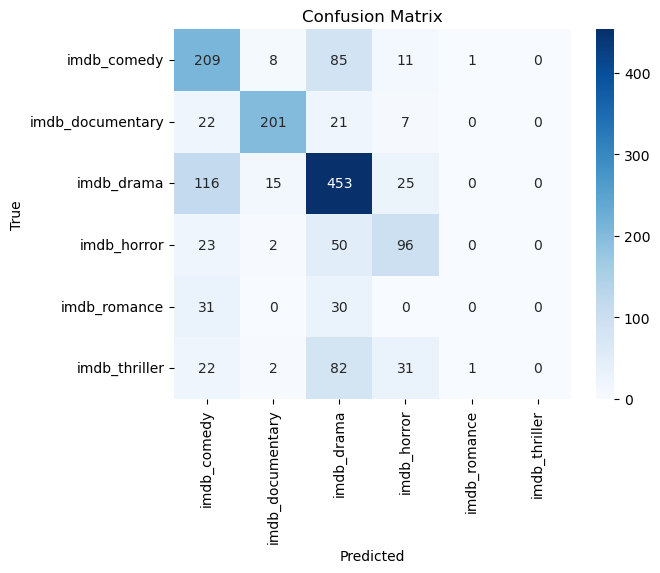

In [12]:
model = make_pipeline(CountVectorizer(ngram_range = (1,1), stop_words = list(en_stop)), MultinomialNB())
model.fit(X_train, y_train_encoded)
y_pred = model.predict(X_test)
print(f"Classification Report:\n", classification_report(y_test, encoder.inverse_transform(y_pred)))
cm = confusion_matrix(y_test_encoded, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=encoder.classes_, yticklabels=encoder.classes_)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()